In [52]:
# !pip install legacy-cgi opendatasets --quiet
# import opendatasets as od
# od.download("https://www.kaggle.com/puneet6060/intel-image-classification")

In [53]:
import torch
import torch.nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import random
from PIL import Image
import numpy as np
import pandas as pd
import os
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print (device)
print(os.listdir("/kaggle/input"))

cuda
['datasets']


In [54]:
# This time we write transform function first and use that while fetching the dataset

train_transform = transforms.Compose ([

transforms.Resize((128,128)),
transforms.RandomHorizontalFlip(p=0.5),
transforms.RandomRotation(15),
transforms.ColorJitter(brightness = 0.2 ,contrast = 0.2),
transforms.ToTensor(),
transforms.ConvertImageDtype(torch.float)

])
val_transform = transforms.Compose ([

transforms.Resize((128,128)),
transforms.ToTensor(),
transforms.ConvertImageDtype(torch.float)

])

In [55]:
BATCH_SIZE =  16
LR = 1e-3
EPOCHS = 20
import os



In [56]:
import os
from torchvision.datasets import ImageFolder

# Base directory based on your output
base_path = "/kaggle/input/datasets/puneet6060/intel-image-classification"

# Check for double nesting (common with opendatasets downloads)
if os.path.exists(os.path.join(base_path, "seg_train", "seg_train")):
    TRAIN_DIR = os.path.join(base_path, "seg_train", "seg_train")
    VAL_DIR = os.path.join(base_path, "seg_test", "seg_test")
else:
    TRAIN_DIR = os.path.join(base_path, "seg_train")
    VAL_DIR = os.path.join(base_path, "seg_test")

print(f"Using TRAIN_DIR: {TRAIN_DIR}")
print(f"Using VAL_DIR:   {VAL_DIR}")

train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = ImageFolder(VAL_DIR, transform=val_transform)

print("Classes:", train_dataset.classes)
NUM_CLASSES = len(train_dataset.classes)

Using TRAIN_DIR: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Using VAL_DIR:   /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [57]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [58]:
train_dataloader = DataLoader(train_dataset, batch_size = BATCH_SIZE , shuffle = True,num_workers = 2 ,pin_memory=True,persistent_workers=True, 
    prefetch_factor=2,  )
val_dataloader = DataLoader (val_dataset , batch_size = BATCH_SIZE, shuffle  = False,num_workers = 2 ,pin_memory=True,persistent_workers=True, 
    prefetch_factor=2, )


In [59]:
# visualize data set first
def visualize_sample (dataset , rows = 3 , cols= 3):
  f, axs = plt.subplots (rows, cols , figsize = (cols*2,rows*2))

  for i in range(rows):
    for j in range (cols):
      index = random.randint(0,len(dataset)-1)
      image_path, label = dataset.samples[index]
      image = Image.open(image_path).convert("RGB")
      axs[i,j].imshow(image)
      axs[i,j].set_title(dataset.classes[label] , fontsize = 9 )
      axs[i,j].axis('off')
  plt.tight_layout()
  plt.show()

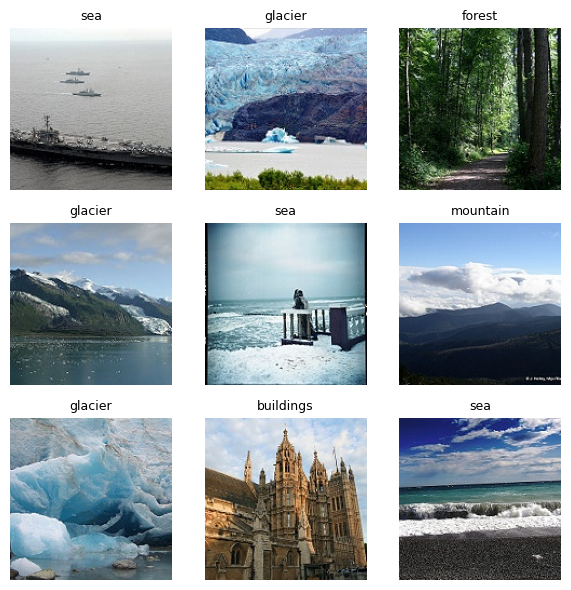

In [60]:
visualize_sample(train_dataset, rows=3, cols=3)

In [61]:
def visualize_augmented (dataset , rows=3, cols=3 ):
  f,axs = plt.subplots (rows,cols ,figsize = (cols*2,rows*2))

  for i in range(rows):
    for j in range(cols):

      index = random.randint(0,len(dataset)-1)
      image_tensor , label = dataset[index]
      image = image_tensor.permute(1,2,0)
      axs[i,j].imshow(image)
      axs[i,j].set_title(dataset.classes[label], fontsize = 9 )
      axs[i,j].axis("off")
  plt.tight_layout()
  plt.show()

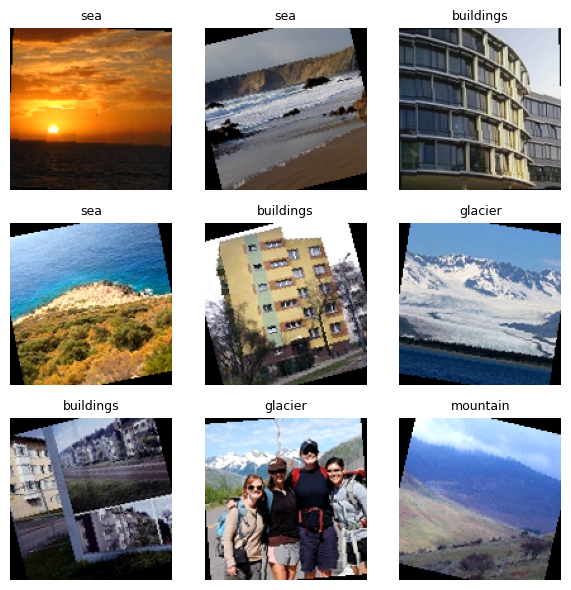

In [62]:
visualize_augmented(train_dataset,3,3)

In [63]:
def build_transfer_model (num_classes:int):
  model = models.googlenet(weights= models.GoogLeNet_Weights.DEFAULT)

  for param in model.parameters():
    param.requires_grad = False

  model.fc = torch.nn.Linear(model.fc.in_features , num_classes)
  model.to(device)
  return model

In [64]:
def unfreeze_last_layer(model):
  for param in model.inception5b.parameters():
    param.requires_grad = True
  return model

In [65]:
model = build_transfer_model(NUM_CLASSES)
model = unfreeze_last_layer(model)
trainable_params = filter (lambda p : p.requires_grad,model.parameters() )
optimizer = Adam (trainable_params , lr = LR , betas= (0.9,0.999) ,weight_decay=1e-4)
scheduler = ReduceLROnPlateau (optimizer , mode = 'min' ,factor = 0.5 ,patience=2)
losscal = torch.nn.CrossEntropyLoss()


In [66]:
def train (model , train_dataloader , val_dataloader ,epochs = EPOCHS, patience= 8):
  history = { "train_loss" : [] , "train_acc" : [] , "val_loss" : [] , "val_acc" : [] }
  # we will track these if our model didnt imporve for 3 epochs we will stop our training
  improvement = 0
  best_val_loss = float('inf')

  for epoch in range(epochs):
    model.train()
    train_loss , train_correct , train_total = 0.0 , 0.0 , 0

    for data in train_dataloader:
      image , label = data
      image ,label = image.to(device) , label.to(device)

      optimizer.zero_grad()
      output = model (image)
      loss = losscal(output,label)
      acc = (torch.argmax(output,dim =1 ) ==label ).sum().item()
      loss.backward()
      optimizer.step()

      train_loss += loss.item()
      train_correct += acc
      train_total += label.size(0)

    model.eval()
    val_loss , val_correct , val_total = 0.0 , 0.0 , 0
    with torch.no_grad():
      for data in val_dataloader:
        image , label =  data
        image , label = image.to(device) ,label.to(device)

        output= model(image)
        loss = losscal (output , label)
        acc = (torch.argmax(output,dim =1) == label).sum().item()

        val_loss += loss.item()
        val_correct += acc
        val_total += label.size(0)

    avg_val_loss = val_loss / len(val_dataloader)
    scheduler.step (avg_val_loss)


    history["train_loss"].append(train_loss / len(train_dataloader))
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append (train_correct /train_total)
    history["val_acc"].append(val_correct / val_total)


    # earlier stop check here if model is not improving beyond patience level
    current_lr = optimizer.param_groups[0]['lr']
    if avg_val_loss < best_val_loss :
      best_val_loss = avg_val_loss
      improvement = 0
      torch.save(model.state_dict() , "best_model.pth")
    else :
      improvement +=1

    print(
    f"Epoch {epoch+1}/{epochs} | "
    f"Train Loss: {history['train_loss'][-1]:.4f} | "
    f"Train Acc: {history['train_acc'][-1]:.4f} | "
    f"Val Loss: {history['val_loss'][-1]:.4f} | "
    f"Val Acc: {history['val_acc'][-1]:.4f} | "
    f"LR: {current_lr:.6f}"
    )

    if improvement >= patience :
      print ("Model is not improving so we stop it earlier ")
      break
  model.load_state_dict(torch.load("best_model.pth"))
  return history


In [67]:
runmodel = train(model,train_dataloader ,val_dataloader,EPOCHS,8)

Epoch 1/20 | Train Loss: 0.5362 | Train Acc: 0.8047 | Val Loss: 0.3955 | Val Acc: 0.8527 | LR: 0.001000
Epoch 2/20 | Train Loss: 0.4350 | Train Acc: 0.8416 | Val Loss: 0.3716 | Val Acc: 0.8703 | LR: 0.001000
Epoch 3/20 | Train Loss: 0.4123 | Train Acc: 0.8483 | Val Loss: 0.4972 | Val Acc: 0.8243 | LR: 0.001000
Epoch 4/20 | Train Loss: 0.3869 | Train Acc: 0.8578 | Val Loss: 0.4537 | Val Acc: 0.8580 | LR: 0.001000
Epoch 5/20 | Train Loss: 0.3711 | Train Acc: 0.8641 | Val Loss: 0.3515 | Val Acc: 0.8723 | LR: 0.001000
Epoch 6/20 | Train Loss: 0.3587 | Train Acc: 0.8690 | Val Loss: 0.3946 | Val Acc: 0.8483 | LR: 0.001000
Epoch 7/20 | Train Loss: 0.3418 | Train Acc: 0.8752 | Val Loss: 0.3304 | Val Acc: 0.8750 | LR: 0.001000
Epoch 8/20 | Train Loss: 0.3497 | Train Acc: 0.8712 | Val Loss: 0.3848 | Val Acc: 0.8630 | LR: 0.001000
Epoch 9/20 | Train Loss: 0.3338 | Train Acc: 0.8774 | Val Loss: 0.3210 | Val Acc: 0.8887 | LR: 0.001000
Epoch 10/20 | Train Loss: 0.3325 | Train Acc: 0.8785 | Val Loss:

In [68]:
def graphi(history):
  rows,cols = 1, 2
  f , axs = plt.subplots(rows,cols,figsize=(10,5))
  axs[0].plot(history["train_loss"], label ="Train Loss")
  axs[0].plot(history["val_loss"] , label ="Validation Loss")
  axs[0].set_title("Loss Plot")
  axs[0].set_xlabel("Epochs")
  axs[0].set_ylabel("Loss")
  axs[0].legend()

  axs[1].plot(history["train_acc"], label ="Train Accuracy")
  axs[1].plot(history["val_acc"] , label ="Validation Accuracy")
  axs[1].set_title("Validation Plot")
  axs[1].set_xlabel("Epochs")
  axs[1].set_ylabel("Accuracy")
  axs[1].legend()
  plt.show()

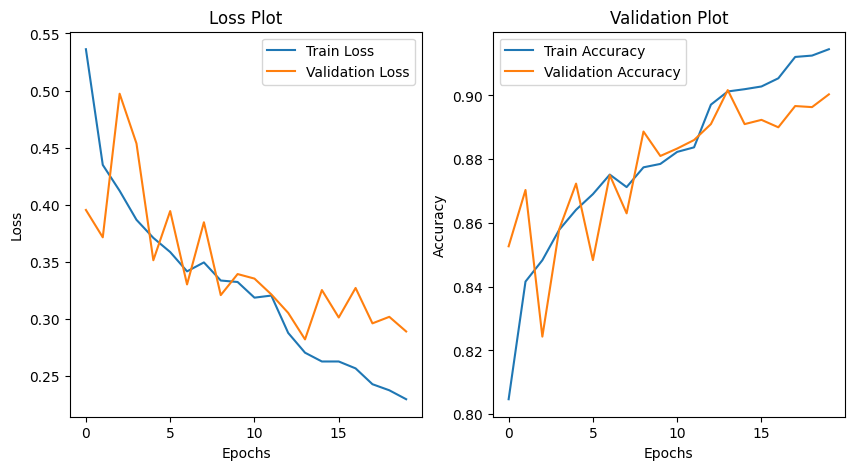

In [69]:
graphi (runmodel)